# 持久性
LangGraph 内置了一个持久层，可以将图状态保存为检查点(checkpoint)。当您使用检查点编译图时，执行的每一步都会保存图状态的快照，并将其组织成线程。这支持人机协作工作流、对话式记忆、时间旅行调试和容错执行。

- 人机协调 允许人检查、中断和批准图步骤，并且图必须在人员更新状态后能够恢复执行。
- 记忆 允许在交互之间保留 “记忆” 。对于重复的人际交互（例如对话），任何后续消息都可以发送到同一线程，该线程会保留对先前消息的记忆
- 时间旅行 使用户能够重放之前的图执行过程，以查看和/或调试特定的图步骤。此外，检查点还允许在任意检查点对图状态进行分支，以探索其他可能的路径。
- 容错性 提供容错性和错误恢复能力：如果一个或多个节点在给定的步骤中发生故障，可以从最后一个成功步骤重新开始您的图。
- 待处理写入 当图节点在某个超级步骤执行过程中失败时，LangGraph 会存储来自该超级步骤中其他成功完成的节点的待处理检查点写入。当您从该超级步骤恢复图执行时，无需重新运行已成功完成的节点。

## 核心概念
### Threads 线程
线程是分配给每个由检查点保存的检查点的唯一 ID 或线程标识符。它包含一系列运行的累积状态。当执行一次运行时，助手底层图的状态将被持久化到该线程中。
使用检查点调用图时， 必须在配置的 configurable 部分中指定 thread_id ：
`{"configurable": {"thread_id": "1"}}  `

检查点器使用 thread_id 作为存储和检索检查点的主键。如果没有 thread_id，检查点器将无法保存状态或在中断后恢复执行，因为检查点器使用 thread_id 来加载已保存的状态。
### checkpoints 检查点
线程在特定时间点的状态称为检查点。检查点是每个超级步骤保存的图状态快照，由 StateSnapshot 对象表示。
### Super-steps  超级步
LangGraph 在每个超级步骤边界处创建一个检查点。超级步骤是图中的单个“刻度”，其中所有被调度到该步骤的节点都会执行（可能并行执行）。对于像 START -> A -> B -> END 这样的顺序图，输入、节点 A 和节点 B 分别对应不同的超级步骤——每个超级步骤之后都会产生一个检查点。

In [27]:
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("GLM_API_KEY")
base_url = os.getenv("GLM_BASE_URL")

model = ChatOpenAI(
    model="glm-4.6",
    api_key=api_key,
    base_url=base_url,
    temperature=0
)

In [28]:
from langgraph.graph import StateGraph, START, END
from langgraph import graph
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from typing import Annotated
from typing_extensions import TypedDict
from operator import add

class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]

def node_a(state: State):
    return {"foo": "a", "bar": ["a"]}

def node_b(state: State):
    return {"foo": "b", "bar": ["b"]}


workflow = StateGraph(State)
workflow.add_node(node_a)
workflow.add_node(node_b)
workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")
workflow.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

config: RunnableConfig = {"configurable": {"thread_id": "1"}}
graph.invoke({"foo": "", "bar":[]}, config)

{'foo': 'b', 'bar': ['a', 'b']}

### Checkpoint namespace  检查点命名空间
每个检查点都有一个 checkpoint_ns （检查点命名空间）字段，用于标识它所属的图或子图：
- `""` （空字符串）：检查点属于父（根）图。
- `"node_name:uuid"` ：检查点属于作为给定节点调用的子图。对于嵌套子图，命名空间用 | 分隔符连接（例如， "outer_node:uuid|inner_node:uuid" ）。

可以通过配置从节点内部访问检查点命名空间：
```python
from langchain_core.runnables import RunnableConfig

def my_node(state: State, config: RunnableConfig):
    checkpoint_ns = config["configurable"]["checkpoint_ns"]
    # "" for the parent graph, "node_name:uuid" for a subgraph
```

## Get and update state  获取和更新状态
与已保存的图状态交互时， 必须指定线程标识符 。可以通过调用 graph.get_state(config) 查看图的最新状态。这将返回一个 StateSnapshot 对象，该对象对应于配置中提供的线程 ID 关联的最新检查点，或者如果提供了线程的检查点 ID，则返回与该检查点关联的检查点。



In [ ]:
# # get the latest state snapshot
# config = {"configurable": {"thread_id": "1"}}
# graph.get_state(config)

# get a state snapshot for a specific checkpoint_id
config = {"configurable": {"thread_id": "1", "checkpoint_id": "1f11fab8-8ad9-6938-8000-28cf7a60573f"}}
graph.get_state(config)

### LangGraph `StateSnapshot` 结构

`StateSnapshot` = **某一步 Graph 执行的完整状态快照**  
用于 **checkpoint / 恢复执行 / 调试 / time-travel**

---

#### 完整字段

| 字段 | 类型 | 作用 |
|-----|-----|-----|
| `values` | dict | 当前 Graph 的 state（reducer 合并后的完整状态） |
| `next` | tuple[str] | 下一步要执行的节点 |
| `config` | dict | 当前执行配置（包含 `thread_id`、`checkpoint_id` 等） |
| `metadata` | dict | 执行元信息（step、source、parents 等） |
| `created_at` | str(datetime) | checkpoint 创建时间 |
| `parent_config` | dict | 父 checkpoint 的配置（用于形成 checkpoint DAG） |
| `tasks` | tuple[PregelTask] | 本 step 执行的任务信息 |
| `interrupts` | tuple | 中断信息（Human-in-the-loop / agent pause 等） |

---

#### `tasks`（PregelTask）子结构

| 字段 | 作用 |
|-----|-----|
| `id` | 任务唯一 ID |
| `name` | 执行的节点名称 |
| `path` | 执行路径 |
| `result` | 节点执行输出 |
| `error` | 执行错误（如果有） |
| `interrupts` | 任务级中断信息 |
| `state` | 任务执行时的局部 state |

---


### Get state history  获取州历史
通过调用 graph.get_state_history(config) 获取给定线程的完整图执行历史记录。这将返回一个与配置中提供的线程 ID 关联的 StateSnapshot 对象列表。重要的是，检查点将按时间顺序排列，最新的检查点/ StateSnapshot 位于列表顶部。

In [ ]:
config = {"configurable": {"thread_id": "1"}}
list(graph.get_state_history(config))

### Find a specific checkpoint 找到一个特定的检查点
可以筛选状态历史记录，查找符合特定条件的检查点：

In [ ]:
history = list(graph.get_state_history(config))

# Find the checkpoint before a specific node executed
before_node_b = next(s for s in history if s.next == ("node_b",))

# Find a checkpoint by step number
step_2 = next(s for s in history if s.metadata["step"] == 2)

# Find checkpoints created by update_state
forks = [s for s in history if s.metadata["source"] == "update"]

# before_node_b
step_2
# step_2, forks
# # Find the checkpoint where an interrupt occurred
# interrupted = next(
#     s for s in history
#     if s.tasks and any(t.interrupts for t in s.tasks)
# )

### Replay  重播
重放功能会重新执行先前检查点之后的步骤。使用先前的 checkpoint_id 调用图，即可重新运行该检查点之后的节点。检查点之前的节点将被跳过（因为它们的结果已被保存）。检查点之后的节点将被重新执行，包括所有 LLM 调用、API 请求或中断 ——这些操作在重放期间始终会被重新触发。
### Update state  更新状态
可以使用 update_state 编辑图状态。这将创建一个包含更新值的新检查点，而不会修改原始检查点。此更新与节点更新的处理方式相同：值会在定义时通过 reducer 函数传递。
可以选择指定 as_node 来控制更新被视为来自哪个节点，这会影响接下来执行更新的节点。

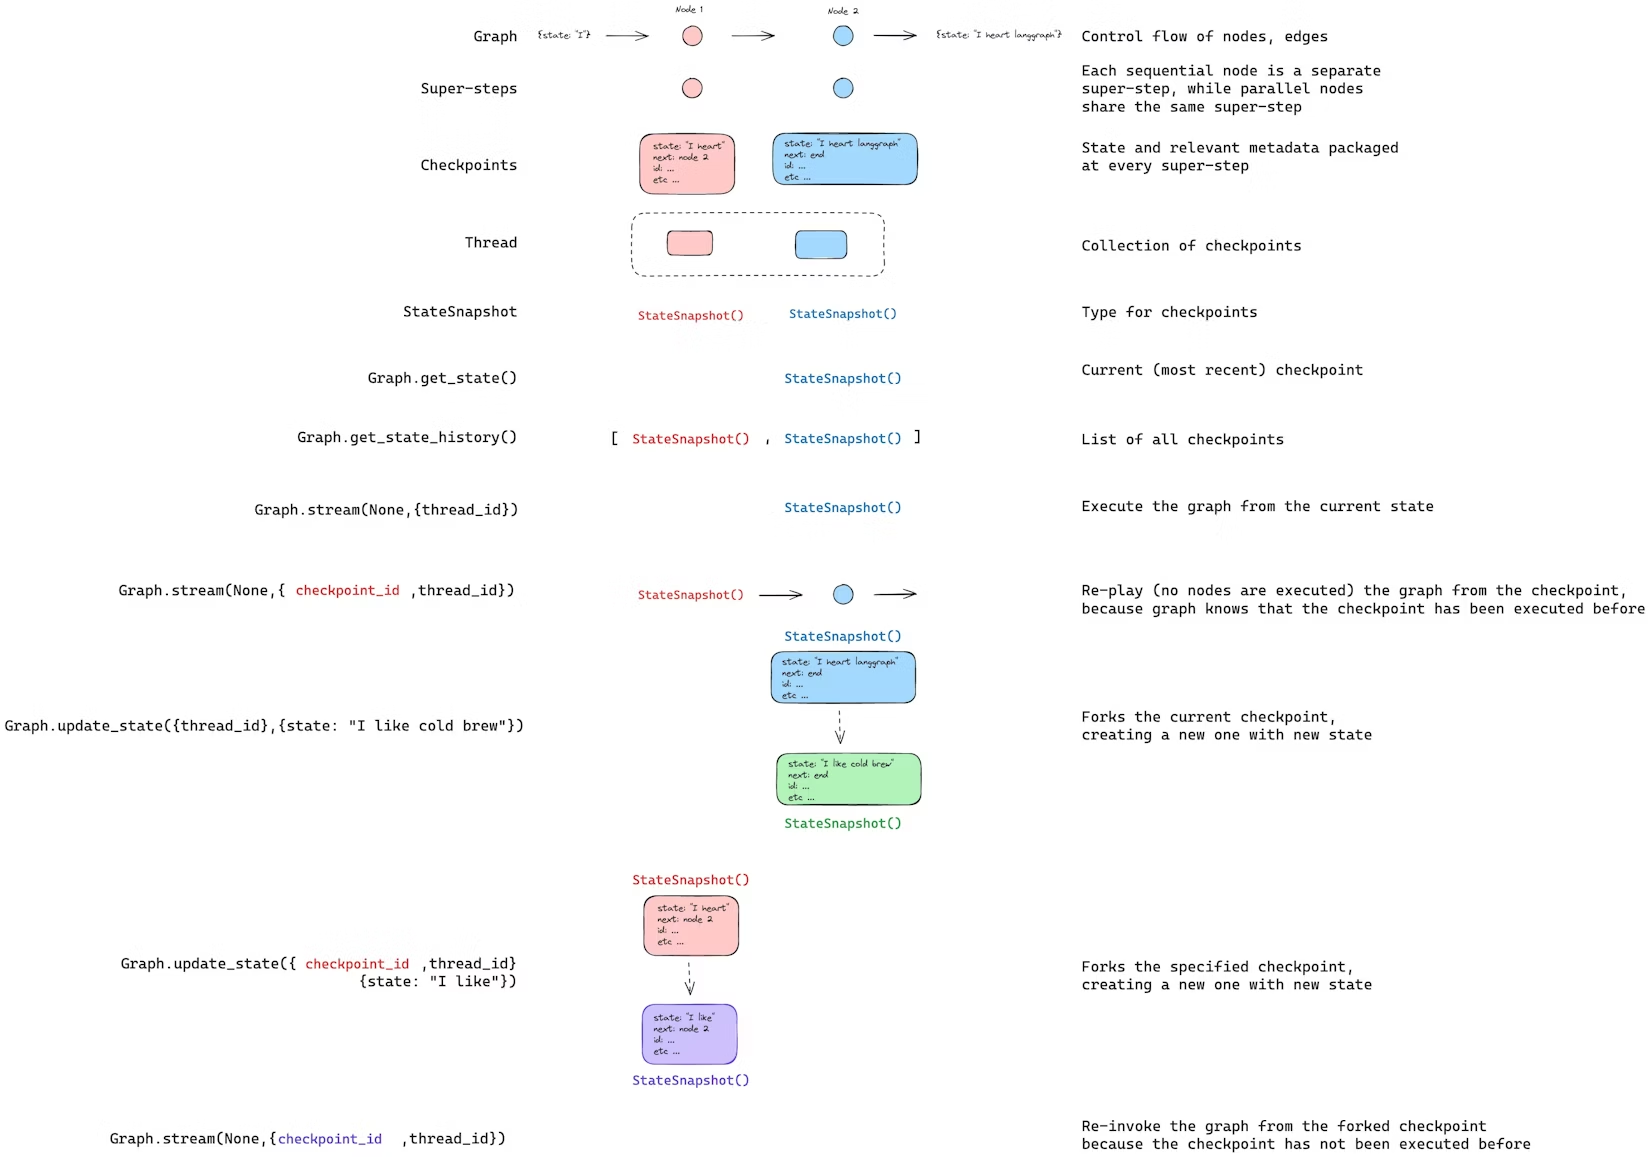

## Memory store  存储器
> LangGraph API 自动处理存储 使用 LangGraph API 时，无需手动实现或配置存储。API 会在后台为您处理所有存储基础设施。

> InMemoryStore 适用于开发和测试。对于生产环境，请使用持久化存储，例如 PostgresStore 或 RedisStore 。所有实现都继承自 BaseStore ，BaseStore 是 Node 函数签名中要使用的类型注解。

### Basic usage  基本用法
**Memorys**使用 tuple 进行命名空间划分 。命名空间长度不限，可以代表任何内容，不必与用户相关。

In [ ]:
from langgraph.store.memory import InMemoryStore
store = InMemoryStore()

user_id = "1"
namespace_for_memory = (user_id, "memories")

使用 store.put 方法将内存保存到 store 中的命名空间。执行此操作时，我们需要指定命名空间（如上所述）以及内存的键值对：键是内存的唯一标识符（ memory_id ），值（一个字典）是内存本身。

In [ ]:
import uuid

memory_id = str(uuid.uuid4())
memory = {"food_preference" : "I like pizza"}
store.put(namespace_for_memory, memory_id, memory)

使用 store.search 方法读取命名空间中的内存，该方法会返回给定用户的所有内存列表。列表末尾的内存是最近的内存。
每种内存类型都是一个具有特定属性的 Python 类（ Item ）。可以通过使用 .dict 将其转换为字典来访问。

In [ ]:
memories = store.search(namespace_for_memory)
memories[-1].dict()
# {'value': {'food_preference': 'I like pizza'},
#  'key': '07e0caf4-1631-47b7-b15f-65515d4c1843',
#  'namespace': ['1', 'memories'],
#  'created_at': '2024-10-02T17:22:31.590602+00:00',
#  'updated_at': '2024-10-02T17:22:31.590605+00:00'}

具有以下属性：
- `value` ：此内存的值（本身是一个字典）
- `key` ：此命名空间中此内存的唯一键
- `namespace` ：一个字符串元组，表示此内存类型的命名空间
  > 虽然类型为 tuple[str, ...] ，但在转换为 JSON 时可能会被序列化为列表（例如， ['1', 'memories'] ）。
- `created_at` ：此内存创建时的时间戳
- `updated_at` ：此内存更新的时间戳


### Semantic search  语义搜索


In [ ]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

# 初始化 BGE 嵌入模型
hf_embed = HuggingFaceEmbeddings(model_name="BAAI/bge-small-zh-v1.5")  # 也可以用 bge-large

In [ ]:
from langchain.embeddings import init_embeddings

store = InMemoryStore(
    index={
        "embed": hf_embed,  # Embedding provider
        "dims": 512,                              # Embedding dimensions
        "fields": ["food_preference", "$"]              # Fields to embed
    }
)

In [ ]:
# 可以通过配置 fields 参数或在存储记忆时指定 index 参数来控制记忆的哪些部分被嵌入
# Store with specific fields to embed
store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {
        "food_preference": "I love Italian cuisine",
        "context": "Discussing dinner plans"
    },
    index=["food_preference"]  # Only embed "food_preferences" field
)

# Store without embedding (still retrievable, but not searchable)
store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {"system_info": "Last updated: 2024-01-01"},
    index=False
)

In [ ]:
# Find memories about food preferences
# (This can be done after putting memories into the store)
memories = store.search(
    namespace_for_memory,
    query="What does the user like to eat?",
    limit=3  # Return top 3 matches
)
memories

### Using in LangGraph  在 LangGraph 中使用

checkpointer 将状态保存到线程中，而 store 允许存储任意信息以供跨线程访问。



In [ ]:
from dataclasses import dataclass
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

@dataclass
class Context:
    user_id: str

# We need this because we want to enable threads (conversations)
checkpointer = InMemorySaver()

# ... Define the graph ...

# Compile the graph with the checkpointer and store
builder = StateGraph(MessagesState, context_schema=Context)#MessagesState会流动的数据, context_schema=Context)固定环境参数
# ... add nodes and edges ...

graph = builder.compile(checkpointer=checkpointer, store=store)

| 方法   | 特点               |
|--------|--------------------|
| invoke | 一次性返回最终结果 |
| stream | 流式返回每一步更新 |

In [33]:
#在 thread_id=1 的对话环境下，把“hi”送进图，流式执行节点，每步保存 checkpoint，并实时输出状态更新。
# 配置运行参数
# thread_id 用于区分不同对话线程（checkpointer 会根据它加载/保存历史状态）
config = {"configurable": {"thread_id": "1"}}

# 调用 graph 执行对话
# graph.stream() 会以流式方式返回图中每个节点执行后的状态更新
for update in graph.stream(
    
    # 初始输入 state
    # 这里向图中传入一条用户消息
    {"messages": [{"role": "user", "content": "hi"}]},
    
    # 运行配置（包含 thread_id 等信息）
    config,
    
    # 指定流式模式
    # "updates" 表示每个节点执行完成后返回该节点对 state 的更新
    # 其它模式例如：
    #   "values" -> 返回完整 state
    #   "messages" -> 专门流式输出消息
    stream_mode="updates",
    
    # 运行上下文（context）
    # 不属于 state，不参与 reducer，也不会写入 checkpoint
    # 常用于传递 user_id、tenant_id、权限信息等环境变量
    context=Context(user_id="1"),
):
    
    # 打印每个节点执行后的状态更新
    print(update)

{'node_a': {'foo': 'a', 'bar': ['a']}}
{'node_b': {'foo': 'b', 'bar': ['b']}}


可以使用 `Runtime` 对象访问任何节点中的 store 和 user_id 。将 `Runtime`作为参数添加到节点函数时，LangGraph 会自动注入 Runtime

In [ ]:
from langgraph.runtime import Runtime
from dataclasses import dataclass

@dataclass
class Context:
    user_id: str

async def update_memory(state: MessagesState, runtime: Runtime[Context]):

    # Get the user id from the runtime context
    user_id = runtime.context.user_id

    # Namespace the memory
    namespace = (user_id, "memories")

    # ... Analyze conversation and create a new memory

    # Create a new memory ID
    memory_id = str(uuid.uuid4())

    # We create a new memory
    await runtime.store.aput(namespace, memory_id, {"memory": memory})

In [ ]:
async def call_model(state: MessagesState, runtime: Runtime[Context]):
    # Get the user id from the runtime context
    user_id = runtime.context.user_id

    # Namespace the memory
    namespace = (user_id, "memories")

    # Search based on the most recent message
    memories = await runtime.store.asearch(
        namespace,
        query=state["messages"][-1].content,
        limit=3
    )
    info = "\n".join([d.value["memory"] for d in memories])

创建一个新线程，只要 user_id 相同，仍然可以访问相同的内存。

In [39]:
# Invoke the graph on a new thread
config = {"configurable": {"thread_id": "2"}}

# Let's say hi again
for update in graph.stream(
    {"messages": [{"role": "user", "content": "hi, tell me about my memories"}]},
    config,
    stream_mode="values",
    context=Context(user_id="1"),
):
    print(update)

{'foo': 'a', 'bar': ['a', 'b', 'a']}
{'foo': 'b', 'bar': ['a', 'b', 'a', 'b']}


使用 LangSmith 时，无论是在本地（例如在 Studio 中）还是托管在 LangSmith 服务器上 ，默认情况下都可以使用基础存储，无需在图编译期间指定。但是，要启用语义搜索，您需要在 langgraph.json 文件中配置索引设置。
```json
{
    ...
    "store": {
        "index": {
            "embed": "openai:text-embeddings-3-small",
            "dims": 1536,
            "fields": ["$"]
        }
    }
}
```

## Checkpointer libraries  检查点库
- langgraph-checkpoint ：检查点保存器 ( BaseCheckpointSaver ) 和序列化/反序列化接口 ( SerializerProtocol ) 的基础接口。包含用于实验的内存检查点实现 ( InMemorySaver )。LangGraph 已包含 langgraph-checkpoint 。
- langgraph-checkpoint-sqlite ：LangGraph 检查点器的实现，使用 SQLite 数据库（ SqliteSaver / AsyncSqliteSaver ）。非常适合实验和本地工作流程。需要单独安装。
- langgraph-checkpoint-postgres ：一个使用 Postgres 数据库（ PostgresSaver / AsyncPostgresSaver ）的高级检查点工具，LangSmith 中也使用了该工具。非常适合生产环境使用。需要单独安装。
- langgraph-checkpoint-cosmosdb ：LangGraph 检查点器的实现，使用 Azure Cosmos DB（ CosmosDBSaver / AsyncCosmosDBSaver ）。非常适合在 Azure 生产环境中使用。支持同步和异步操作。需要单独安装。
### Checkpointer interface  检查点接口
每个检查点都符合 BaseCheckpointSaver 接口，并实现以下方法：
- `.put` - 存储包含其配置和元数据的检查点。
- `.put_writes` - 存储与检查点关联的中间写入（即待处理的写入 ）。  记录节点执行产生的副作用，用于崩溃恢复时避免重复执行。
- `.get_tuple` - 使用给定的配置（ thread_id 和 checkpoint_id ）获取检查点元组。这用于在 graph.get_state() 中填充 StateSnapshot 。
- `.list` - 列出符合给定配置和筛选条件的检查点。用于在 graph.get_state_history() 中填充状态历史记录。

如果检查点与异步图执行一起使用（即通过 .ainvoke 、 .astream 、 .abatch 执行图），则将使用上述方法的异步版本（ .aput 、 .aput_writes 、 .aget_tuple 、 .alist ）。
要异步运行图，您可以使用 InMemorySaver ，或者 Sqlite/Postgres 检查点的异步版本 AsyncSqliteSaver / AsyncPostgresSaver 检查点。

### Serializer  序列化器
当检查点保存图状态时，需要序列化状态中的通道值。这是通过序列化器对象实现的。
langgraph_checkpoint 定义了用于实现序列化的协议 ，并提供了一个默认实现（ JsonPlusSerializer ），该实现可以处理各种类型，包括 LangChain 和 LangGraph 原语、日期时间、枚举等等。

#### Serialization with pickle 使用 pickle 进行序列化

> msgpack = 更快、更小的 JSON（二进制版）

如果要对当前 msgpack 编码器不支持的对象（例如 Pandas 数据帧）回退到 pickle 格式，可以使用 JsonPlusSerializer 的 pickle_fallback 参数：



In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer

# ... Define the graph ...
graph.compile(
    checkpointer=InMemorySaver(serde=JsonPlusSerializer(pickle_fallback=True))
)

#### Encryption  加密
检查点可以选择性地加密所有持久化状态。
要启用此功能，请将 EncryptedSerializer 实例传递给任何 BaseCheckpointSaver 实现的 serde 参数。创建加密序列化器的最简单方法是通过 from_pycryptodome_aes ，它会从 LANGGRAPH_AES_KEY 环境变量中读取 AES 密钥（或接受一个 key 参数）：

In [ ]:
import sqlite3

from langgraph.checkpoint.serde.encrypted import EncryptedSerializer
from langgraph.checkpoint.sqlite import SqliteSaver

serde = EncryptedSerializer.from_pycryptodome_aes()  # reads LANGGRAPH_AES_KEY
checkpointer = SqliteSaver(sqlite3.connect("checkpoint.db"), serde=serde)

In [ ]:
from langgraph.checkpoint.serde.encrypted import EncryptedSerializer
from langgraph.checkpoint.postgres import PostgresSaver

serde = EncryptedSerializer.from_pycryptodome_aes()
checkpointer = PostgresSaver.from_conn_string("postgresql://...", serde=serde)
checkpointer.setup()

要使用其他加密方案，实现 CipherProtocol 并将其提供给 EncryptedSerializer 。